# Reconstruction data plotting

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [159]:
# Configure matplotlib for formal report styling (matching Week 13 format)
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'lines.linewidth': 1.8,
    'axes.linewidth': 1.4,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'figure.dpi': 80,
    'legend.fontsize': 14
})

(513,)


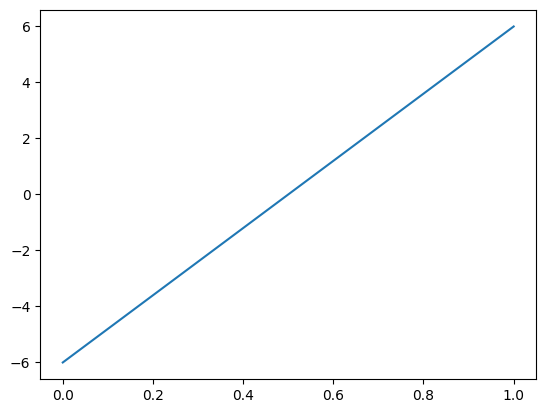

In [5]:
p_out = np.loadtxt('DeconvolvedData/p.out')

print(p_out.shape)

x = np.linspace(0, 1, p_out.shape[0])

plt.plot(x, p_out)

(513,)


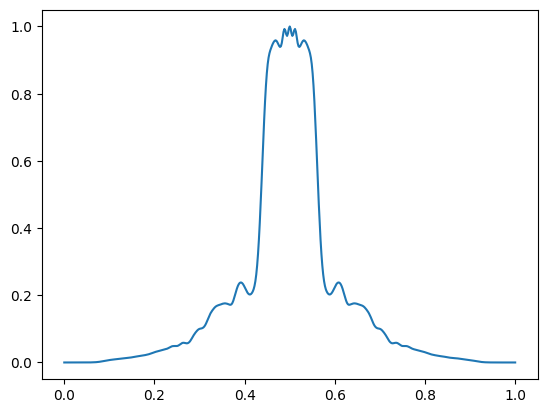

In [34]:
reconstructed_plot = np.loadtxt('DeconvolvedData/reconstructed_plot.out')

print(reconstructed_plot.shape)
x = np.linspace(0, 1, reconstructed_plot.shape[0])
plt.plot(x, reconstructed_plot)
plt.show()


(513, 513)
(513,)
(1001, 1001)


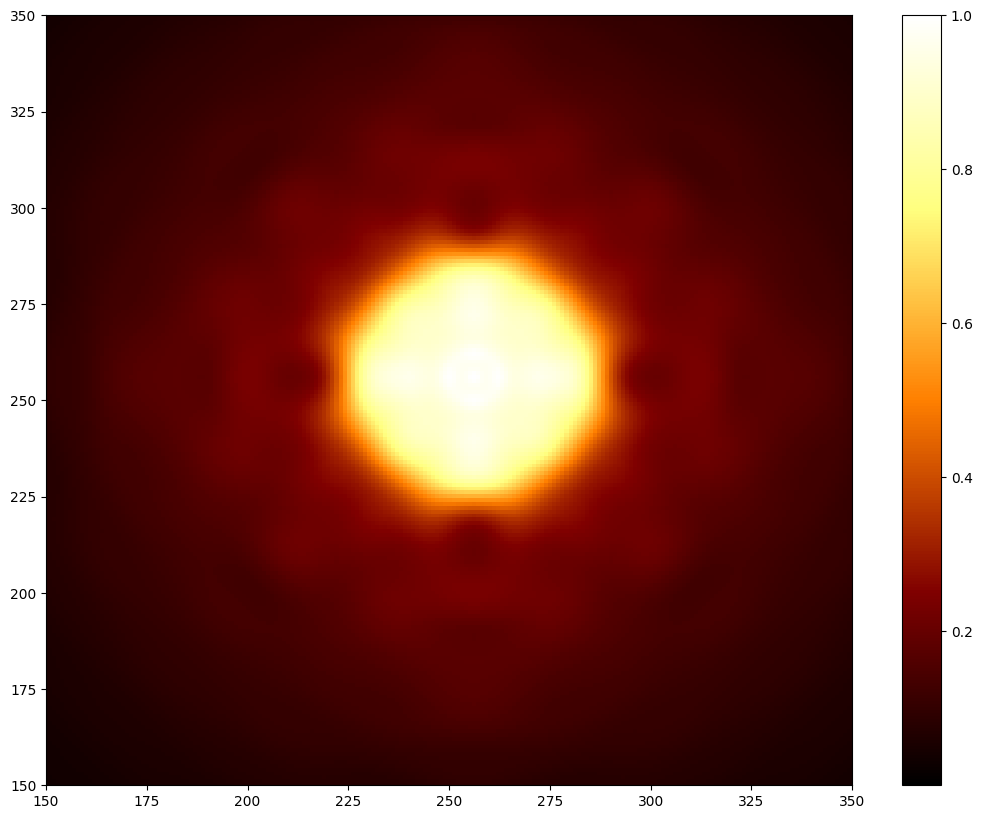

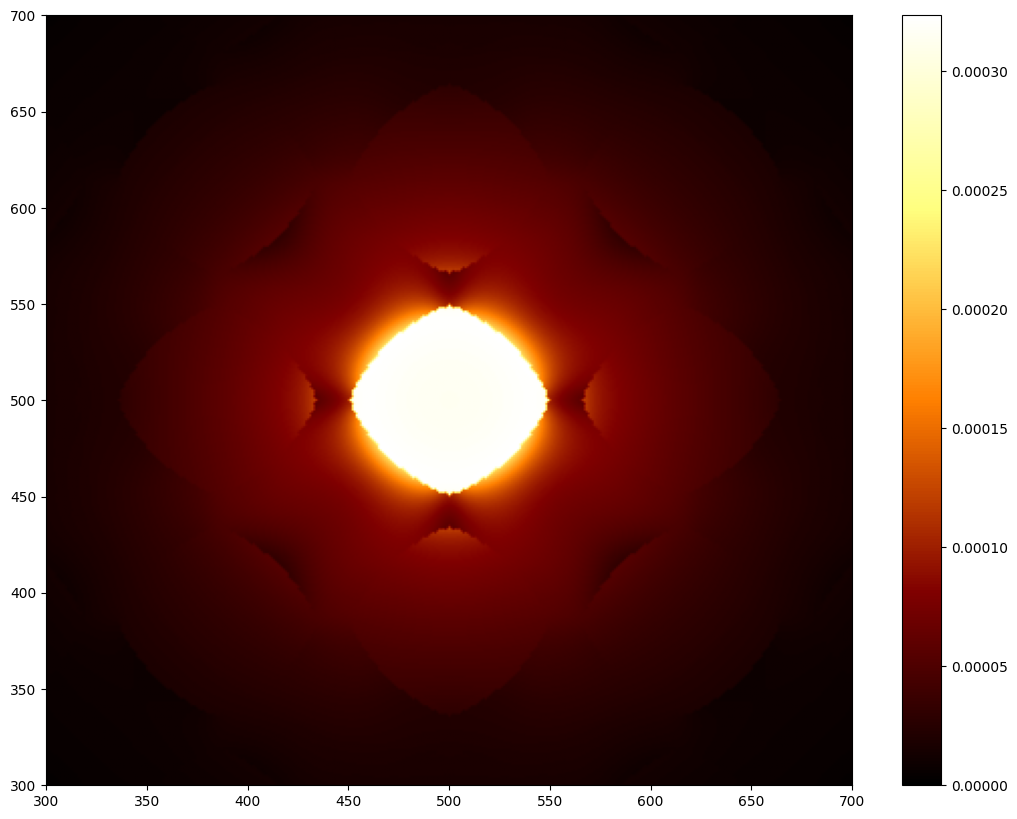

In [72]:
reconstructed_slice = np.loadtxt('DeconvolvedData/reconstructed_slice.out')
reference_slice = np.loadtxt('DeconvolvedData/reference_slice.out')
reference_plot = np.loadtxt('DeconvolvedData/reference_plot.out')
print(reconstructed_slice.shape)
print(reference_plot.shape)
print(reference_slice.shape)

x = reconstructed_slice.shape[1]

plt.figure(figsize=(13, 10))
plt.imshow(reconstructed_slice, aspect='auto', cmap='afmhot')
plt.xlim(150,350)
plt.ylim(150,350)
plt.colorbar()
plt.show()

plt.figure(figsize=(13, 10))
plt.imshow(reference_slice, aspect='auto', cmap='afmhot')
plt.xlim(300, 700)
plt.ylim(300,700)
plt.colorbar()
plt.show()

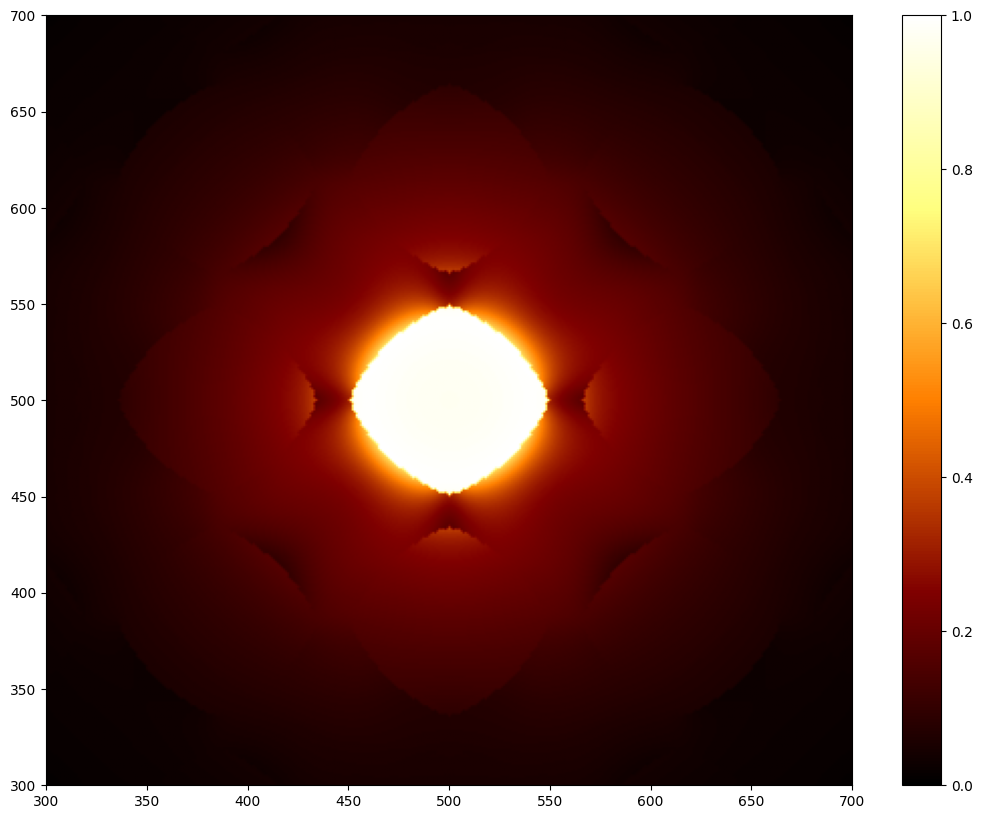

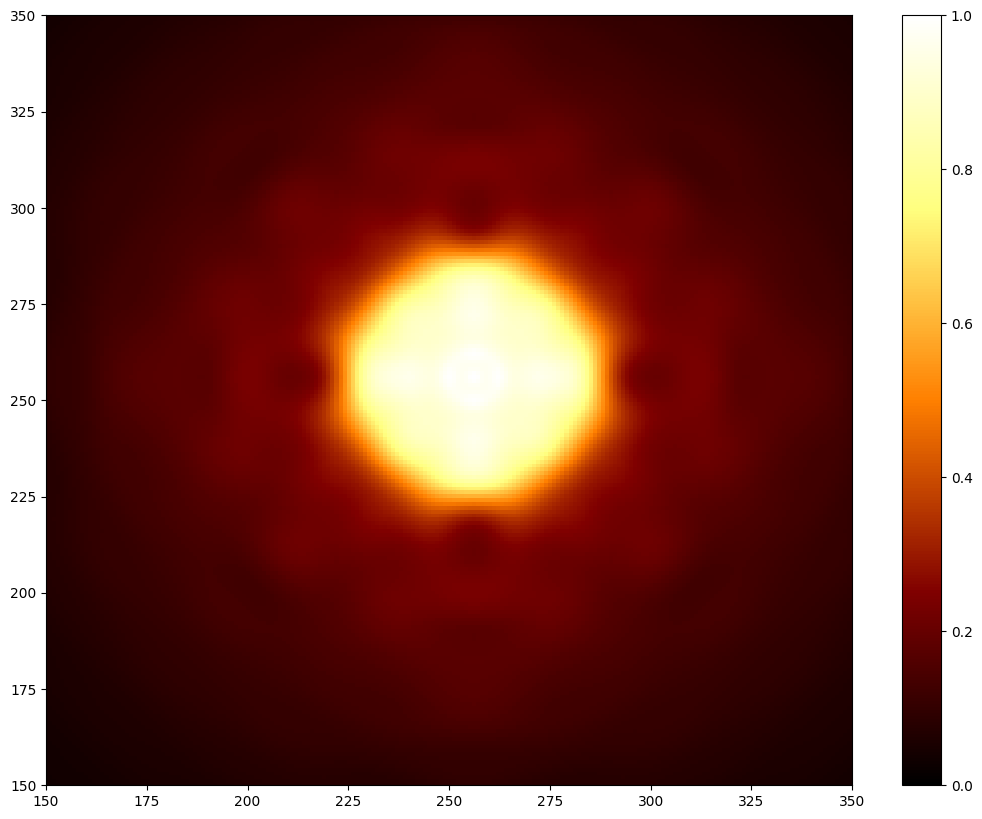

In [77]:
reference_scaled = (reference_slice - reference_slice.min()) / (reference_slice.max() - reference_slice.min())
reconstructed_scaled = (reconstructed_slice - reconstructed_slice.min()) / (reconstructed_slice.max() - reconstructed_slice.min())

plt.figure(figsize=(13, 10))
plt.imshow(reference_scaled, aspect='auto', cmap='afmhot')
plt.xlim(300, 700)
plt.ylim(300,700)
plt.colorbar()
plt.show()

plt.figure(figsize=(13, 10))
plt.imshow(reconstructed_scaled, aspect='auto', cmap='afmhot')
plt.xlim(150,350)
plt.ylim(150,350)
plt.colorbar()
plt.show()


(513, 513)
(513, 513)


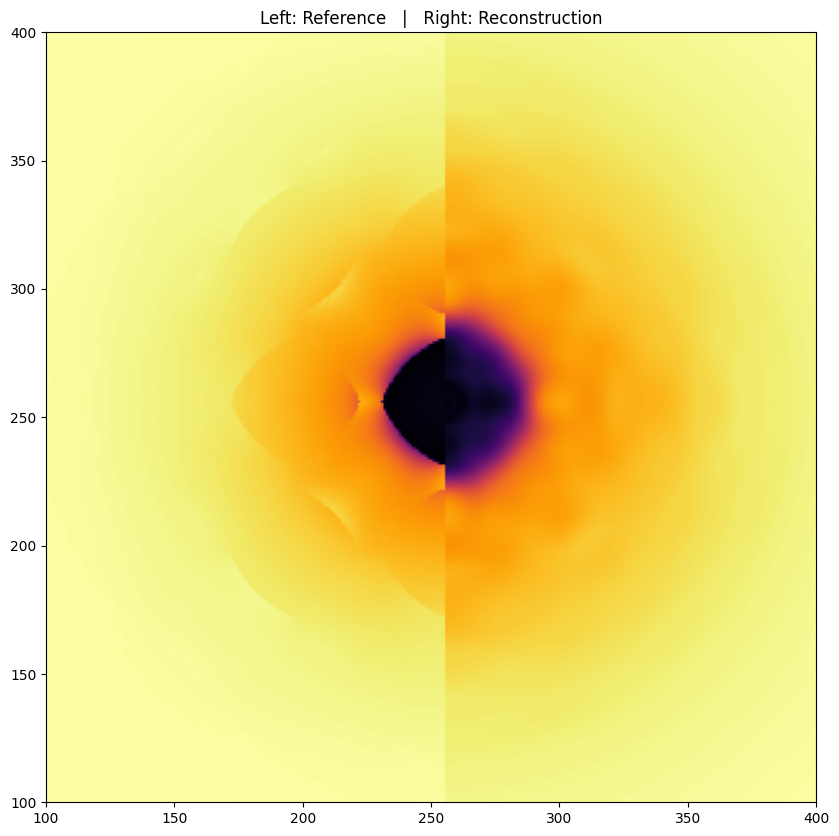

In [90]:
from scipy.ndimage import zoom

scale = reconstructed_slice.shape[0] / reference_slice.shape[0]

reference_rescaled = zoom(reference_scaled, scale)

print(reference_rescaled.shape)
print(reconstructed_scaled.shape)

combined = np.hstack((
    reference_rescaled[:, :reference_rescaled.shape[1]//2],
    reconstructed_scaled[:, reconstructed_scaled.shape[1]//2:]
))

plt.figure(figsize=(13, 10))
plt.imshow(combined, origin='lower', cmap='inferno_r', )
plt.title("Left: Reference   |   Right: Reconstruction")
plt.xlim(100, 400)
plt.ylim(100, 400)
plt.show()

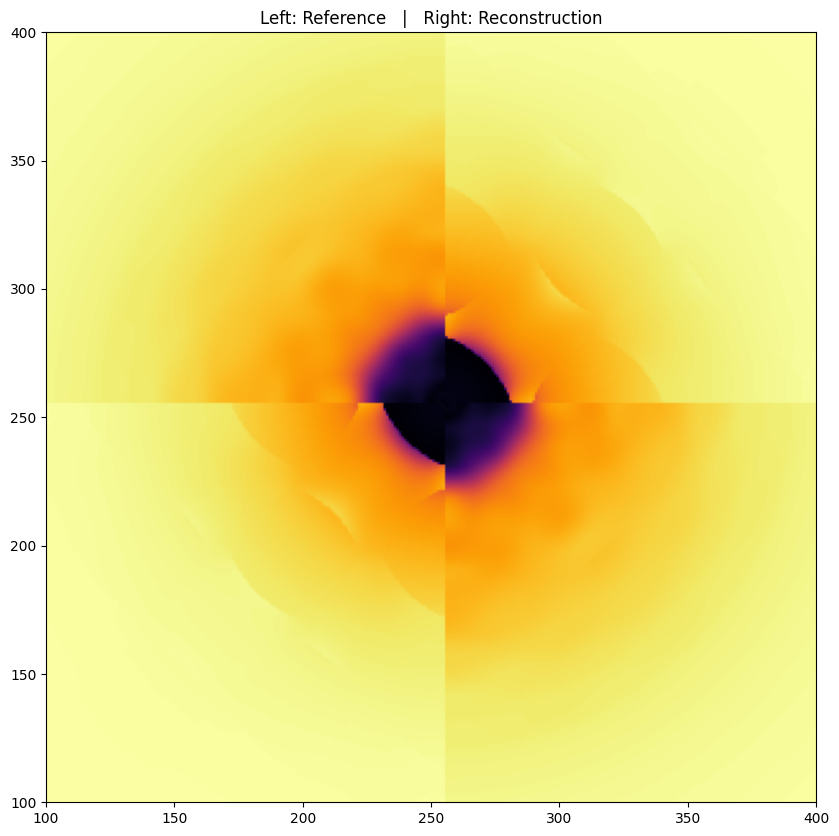

In [ ]:
h, w = reconstructed_scaled.shape

# midpoints
h_mid = h // 2
w_mid = w // 2

combined = np.block([
    [reference_rescaled[:h_mid, :w_mid], reconstructed_scaled[:h_mid, w_mid:]],
    [reconstructed_scaled[h_mid:, :w_mid], reference_rescaled[h_mid:, w_mid:]]
])


# Q1 | Q2
# -------
# Q3 | Q4

# Q1: reference_rescaled[:h_mid, :w_mid]
# Q2: reconstructed_scaled[:h_mid, w_mid:]
# Q3: reconstructed_scaled[h_mid:, :w_mid]
# Q4: reference_rescaled[h_mid:, w_mid:]


plt.figure(figsize=(13, 10))
plt.imshow(combined, origin='lower', cmap='inferno_r', )
plt.title("Quarters")
plt.xlim(100, 400)
plt.ylim(100, 400)
plt.show()

(513,)


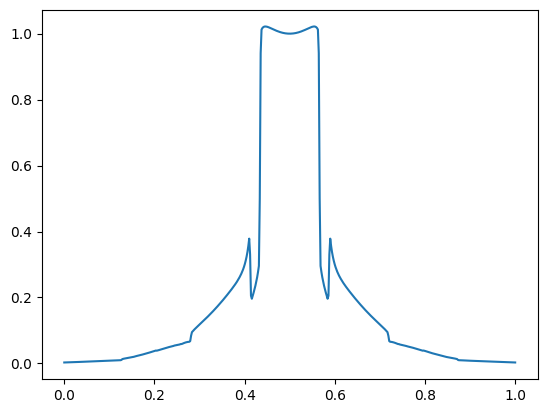

In [46]:
reference_plot = np.loadtxt('DeconvolvedData/reference_plot.out')
print(reference_plot.shape)
plt.plot(x, reference_plot)

(1001, 1001)


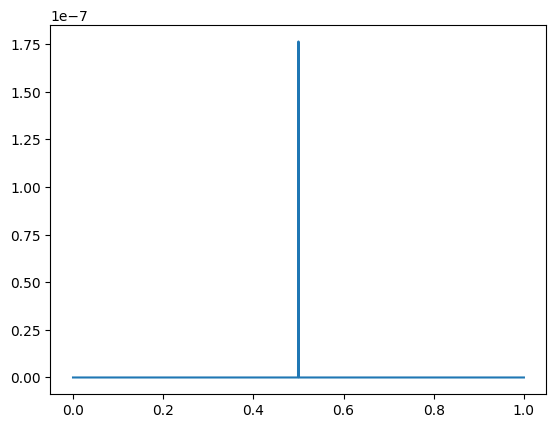

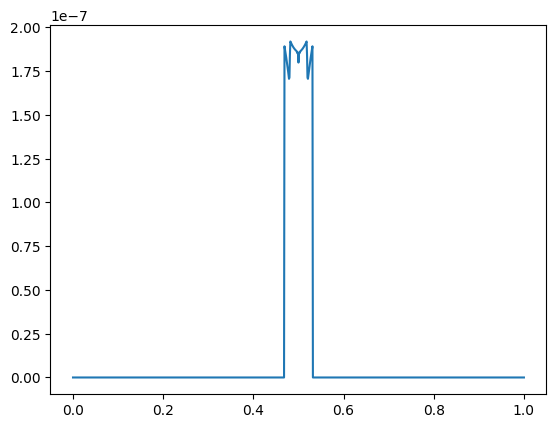

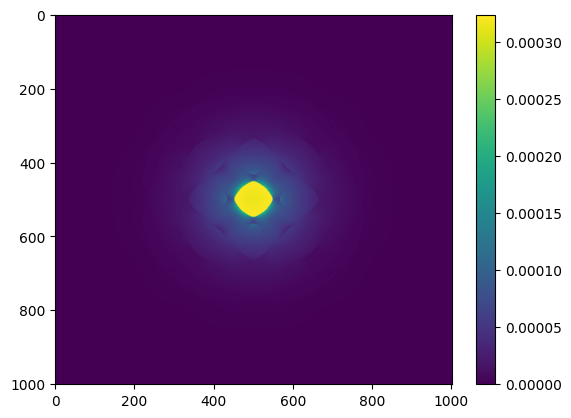

In [35]:
reference_slice = np.loadtxt('DeconvolvedData/reference_slice.out')
print(reference_slice.shape)

x = np.linspace(0, 1, reference_slice.shape[1])

plt.plot(x, reference_slice[0])
plt.show()

plt.plot(x, reference_slice[1])
plt.show()

plt.imshow(reference_slice, aspect='auto', cmap='viridis')
plt.colorbar()
plt.show()


In [ ]:
from scipy.interpolate import RegularGridInterpolator
ref_slice = np.loadtxt("ref.out")
x = np.linspace(-8.0, 8.0, ref_slice.shape[0])
y = np.linspace(-8.0, 8.0, ref_slice.shape[1])
interpolator = RegularGridInterpolator((x, y), ref_slice)
x_new = np.linspace(-6, 6, emd_slice.shape[0])
y_new = np.linspace(-6, 6, emd_slice.shape[1])
x_new_grid, y_new_grid = np.meshgrid(x_new, y_new, indexing='ij')
points = np.array([x_new_grid.flatten(), y_new_grid.flatten()]).T
ref_slice_interpolated = interpolator(points).reshape(emd_slice.shape)  
# ref_slice_interpolated /= ref_slice_interpolated[ref_slice_interpolated.shape[0]//2, ref_slice_interpolated.shape[1]//2]  # Normalize to center value
emd_slice /= emd_slice.max()  # Normalize to max value
ref_slice_interpolated /= ref_slice_interpolated.max()  # Normalize to max value
 

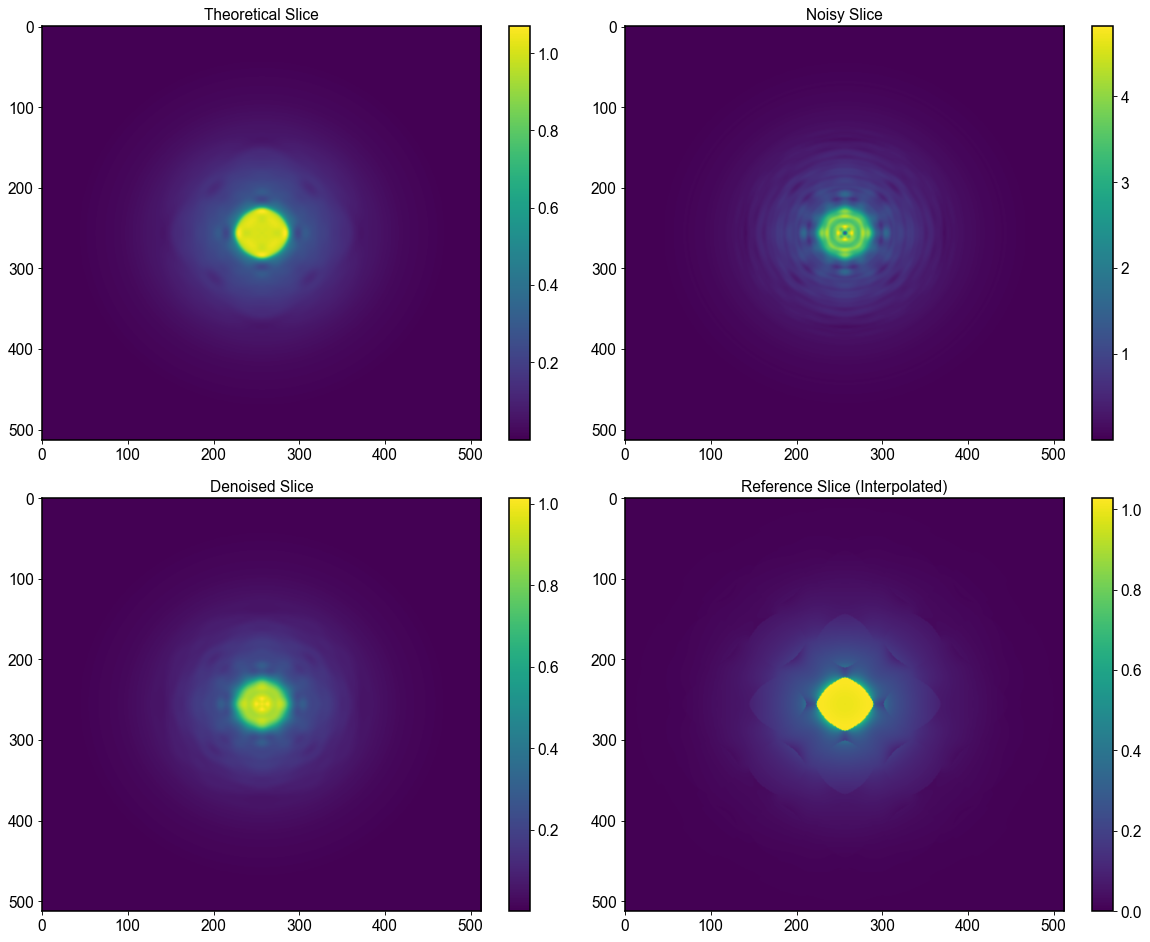

In [193]:
denoised_slice = np.loadtxt("reconstructions/DenoisedData20000/reconstructed_emd_slice.out")
noisy_slice = np.loadtxt("reconstructions/NoisyData20000/reconstructed_emd_slice.out")
theory_slice = np.loadtxt("reconstructions/TheoreticalData/reconstructed_emd_slice.out")
theory_ref_slice = np.loadtxt("reconstructions/DenoisedData20000/ref_slice_interpolated.out")

# Create the figure and subplots consistently
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))  # Optional: Add figsize for better sizing

# Top-left (position 1)
axes[0, 0].imshow(theory_slice, aspect='auto', cmap='viridis')
axes[0, 0].set_title('Theoretical Slice')
plt.colorbar(axes[0, 0].imshow(theory_slice, aspect='auto', cmap='viridis'), ax=axes[0, 0])

# Top-right (position 2)
axes[0, 1].imshow(noisy_slice, aspect='auto', cmap='viridis')
axes[0, 1].set_title('Noisy Slice')
plt.colorbar(axes[0, 1].imshow(noisy_slice, aspect='auto', cmap='viridis'), ax=axes[0, 1])

# Bottom-left (position 3)
axes[1, 0].imshow(denoised_slice, aspect='auto', cmap='viridis')
axes[1, 0].set_title('Denoised Slice')
plt.colorbar(axes[1, 0].imshow(denoised_slice, aspect='auto', cmap='viridis'), ax=axes[1, 0])

# Bottom-right (position 4)
axes[1, 1].imshow(theory_ref_slice, aspect='auto', cmap='viridis')
axes[1, 1].set_title('Reference Slice (Interpolated)')
plt.colorbar(axes[1, 1].imshow(theory_ref_slice, aspect='auto', cmap='viridis'), ax=axes[1, 1])

plt.tight_layout()  # Prevents overlapping
plt.show()



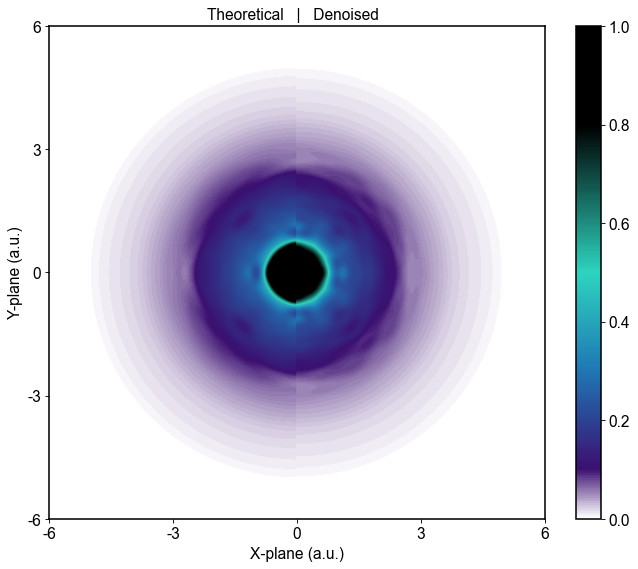

In [197]:
import matplotlib.colors as mcolors
import matplotlib.colors as colors

theory_scaled = (theory_slice - theory_slice.min()) / (theory_slice.max() - theory_slice.min())
noisy_scaled = (noisy_slice - noisy_slice.min()) / (noisy_slice.max() - noisy_slice.min())
denoised_scaled = (denoised_slice - denoised_slice.min()) / (denoised_slice.max() - denoised_slice.min())
ref_scaled = (theory_ref_slice - theory_ref_slice.min()) / (theory_ref_slice.max() - theory_ref_slice.min())

h, w = theory_slice.shape

# midpoints
h_mid = h // 2
w_mid = w // 2

combined = np.block([
    [theory_scaled[:h_mid, :w_mid], denoised_scaled[:h_mid, w_mid:]],
    [theory_scaled[h_mid:, :w_mid], denoised_scaled[h_mid:, w_mid:]]
])

combined_2 = np.block([
    [denoised_scaled[:h_mid, :w_mid], noisy_scaled[:h_mid, w_mid:]],
    [denoised_scaled[h_mid:, :w_mid], denoised_scaled[h_mid:, w_mid:]]
])

colors_1 = [
    (0.0, "white"),
    (0.1, "#3b0f70"),
    (0.3, "#1f77b4"),
    (0.5, "#2dd4bf"), 
    (0.8, "black"),
    (1.0, "black")
]

custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "momentum_cmap",
    colors_1
)


ticks = np.linspace(0, 513, 5)
labels = [-6, -3, 0, 3, 6]


plt.figure(figsize=(10, 8))
plt.imshow(combined, aspect='auto', cmap=custom_cmap)
plt.xlim(100, 400)
plt.ylim(400, 100)
plt.title("Theoretical   |   Denoised  ")
plt.xticks(ticks, labels)
plt.yticks(ticks, labels)
plt.xlabel("X-plane (a.u.)")
plt.ylabel("Y-plane (a.u.)")
plt.gca().invert_yaxis() 
plt.colorbar()
plt.show()

# norm=colors.PowerNorm(gamma=0.5)
